# Return-Only LSTM Volatility Filter + EVT

LSTM volatility filter using the previous 22 percent log-returns. The EVT stage is unchanged from the GARCH pipeline.


In [1]:
import math, random, warnings
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto, jarque_bera, chi2
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    import torch
    import torch.nn as nn
    HAS_TORCH=True
except ImportError:
    HAS_TORCH=False
if not HAS_TORCH:
    raise ImportError('torch is unavailable. Stopping as requested; no substitute architecture will be used.')

warnings.filterwarnings('ignore', category=RuntimeWarning)
sns.set(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
SEEDS=[0,1,2,3,4]
WINDOW=22
HIDDEN_SIZE=24
TRAIN_END=pd.Timestamp('2018-01-01')
NU_FIXED=5.763
TAIL_Q=0.064
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, device={DEVICE}')
print(f'Seeds: {SEEDS}')
print(f'Fixed architecture: one-layer LSTM, hidden_size={HIDDEN_SIZE}, window={WINDOW}')


torch 2.6.0, device=cpu
Seeds: [0, 1, 2, 3, 4]
Fixed architecture: one-layer LSTM, hidden_size=24, window=22


## Shared GPD Helpers

The GPD likelihood and VaR helpers match notebooks 02 and 04.


In [2]:
def gpd_neg_log_pdf(y, xi, sigma, eps=1e-9):
    """GPD negative log-density (loc=0), y > 0. Written ONCE and reused for
    the baseline fit's test evaluation, the neural model's training loss
    (torch mirror below), and the neural model's test evaluation, so no
    model gets a different, hand-tuned notion of likelihood."""
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    z = xi * y / sigma
    one_plus_z = np.clip(1.0 + z, eps, None)
    return np.log(sigma) + (1.0 + 1.0 / xi) * np.log(one_plus_z)


def gpd_cdf(y, xi, sigma, eps=1e-9):
    """GPD CDF (loc=0), for the probability-integral-transform check below."""
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    z = xi * y / sigma
    one_plus_z = np.clip(1.0 + z, eps, None)
    return 1.0 - one_plus_z ** (-1.0 / xi)

_y_check = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
assert np.allclose(-genpareto.logpdf(_y_check, c=0.15, loc=0, scale=0.6), gpd_neg_log_pdf(_y_check, 0.15, 0.6))
assert np.allclose(genpareto.cdf(_y_check, c=0.15, loc=0, scale=0.6), gpd_cdf(_y_check, 0.15, 0.6))
print('gpd_neg_log_pdf / gpd_cdf verified against scipy.stats.genpareto.')

def gpd_var(u, xi, beta, q_u, p):
    """POT/GPD-based standardized-residual quantile z_p at confidence level
    p, given a GPD fit (u, xi, beta) with empirical exceedance rate
    q_u = P(X < u). Valid only when the requested tail probability (1-p)
    does not exceed q_u -- asking for a less extreme quantile than the
    threshold itself sits outside the region the GPD tail was actually fit
    to, so the extrapolation is not meaningful there."""
    if (1 - p) > q_u:
        raise ValueError(f'VaR at p={p} needs tail probability {1-p:.4f}, which exceeds q_u={q_u:.4f}.')
    return u - (beta / xi) * (((1 - q_u) / (1 - p)) ** xi - 1)

def devolatilized_var(z_q, mu_hat, sigma_hat):
    """Convert a standardized-residual quantile z_q to an actual
    return-scale VaR: VaR = mu_hat + sigma_hat * z_q."""
    return mu_hat + sigma_hat * z_q

def gpd_xi_ci(xi_hat, n_exc, z=1.96):
    """Asymptotic standard-error-based CI for the GPD shape MLE (Smith
    1987): Var(xi_hat) ~= (1 + xi_hat)^2 / n_exc for large n_exc."""
    se = (1 + xi_hat) / np.sqrt(n_exc)
    return xi_hat - z * se, xi_hat + z * se, se

def gpd_shape_scale(exceedances, floc=0):
    """MLE fit of a GPD to POSITIVE excesses (x - u for x > u).
    Returns (xi, beta); (nan, nan) if there isn't enough data or the fit fails."""
    exceedances = np.asarray(exceedances, dtype=float)
    exceedances = exceedances[np.isfinite(exceedances) & (exceedances > 0)]
    if len(exceedances) < 10:
        return np.nan, np.nan
    try:
        xi, _, beta = genpareto.fit(exceedances, floc=floc)
        return xi, beta
    except Exception:
        return np.nan, np.nan

def kupiec_pof_test(violations, alpha):
    v=np.asarray(violations,dtype=int); n=len(v); x=int(v.sum())
    ph=np.clip(x/n,1e-12,1-1e-12)
    ll0=(n-x)*np.log(1-alpha)+x*np.log(alpha)
    ll1=(n-x)*np.log(1-ph)+x*np.log(ph)
    lr=-2*(ll0-ll1)
    return lr, 1-chi2.cdf(lr,1)

def christoffersen_independence_test(violations):
    v=np.asarray(violations,dtype=int)
    prev,curr=v[:-1],v[1:]
    n00=int(((prev==0)&(curr==0)).sum()); n01=int(((prev==0)&(curr==1)).sum())
    n10=int(((prev==1)&(curr==0)).sum()); n11=int(((prev==1)&(curr==1)).sum())
    def term(n,p): return 0.0 if n==0 else n*np.log(np.clip(p,1e-12,1-1e-12))
    pi=(n01+n11)/max(n00+n01+n10+n11,1); pi0=n01/max(n00+n01,1); pi1=n11/max(n10+n11,1)
    ll0=term(n00+n10,1-pi)+term(n01+n11,pi)
    ll1=term(n00,1-pi0)+term(n01,pi0)+term(n10,1-pi1)+term(n11,pi1)
    lr=-2*(ll0-ll1)
    return lr, 1-chi2.cdf(lr,1)

def fmt(vals, digits=4):
    a=np.asarray(vals,dtype=float)
    sd=np.nanstd(a,ddof=1) if np.isfinite(a).sum()>1 else 0.0
    return f'{np.nanmean(a):.{digits}f} +/- {sd:.{digits}f}'


gpd_neg_log_pdf / gpd_cdf verified against scipy.stats.genpareto.


## Data

GARCH volatility and mean are converted to percent-return units for comparison.


In [3]:
spy=pd.read_csv('spy.csv')
cols={x.lower():x for x in spy.columns}
prices=spy[[cols['date'], cols['close']]].copy(); prices.columns=['Date','Close']
prices['Date']=pd.to_datetime(prices['Date']); prices=prices.sort_values('Date').reset_index(drop=True)
prices['Return']=100*np.log(prices['Close']/prices['Close'].shift(1))
returns_df=prices.dropna(subset=['Return']).reset_index(drop=True)
std=pd.read_csv('standardized_residuals.csv'); std['Date']=pd.to_datetime(std['Date'])
gp=pd.read_csv('garch_params.csv').iloc[0]
mu_pct=float(gp['Mu'])*100
nu_garch=float(gp['Nu'])
merged=returns_df.merge(std[['Date','t Standardized Residuals','Conditional Volatility']], on='Date', how='left')
merged['GARCH Sigma']=merged['Conditional Volatility']*100
merged['Train']=merged['Date']<TRAIN_END
print(f'GARCH mu percent units: {mu_pct:.6f}; handoff nu={nu_garch:.3f}; fixed LSTM nu={NU_FIXED:.3f}')
print(f"Full return sample: {len(merged):,}; train={merged['Train'].sum():,}; test={(~merged['Train']).sum():,}")
merged.head()


GARCH mu percent units: 0.076445; handoff nu=5.763; fixed LSTM nu=5.763
Full return sample: 10,153; train=8,318; test=1,835


,Date,Close,Return,t Standardized Residuals,Conditional Volatility,GARCH Sigma,Train
0,1985-01-03,164.5700,-0.4849,-0.7118,0.0079,0.7887,True
1,1985-01-04,163.6800,-0.5423,-0.7977,0.0078,0.7756,True
2,1985-01-07,164.2400,0.3416,0.3453,0.0077,0.7679,True
3,1985-01-08,163.9900,-0.1523,-0.3087,0.0074,0.7412,True
4,1985-01-09,165.1800,0.7230,0.9042,0.0072,0.7151,True


In [4]:
def make_sequences(returns, window=WINDOW):
    r=np.asarray(returns,dtype=np.float32); X=[]; y=[]; idx=[]
    for i in range(window,len(r)):
        X.append(r[i-window:i]); y.append(r[i]); idx.append(i)
    return np.asarray(X,dtype=np.float32)[...,None], np.asarray(y,dtype=np.float32), np.asarray(idx,dtype=int)
X_raw,y_all,seq_idx=make_sequences(merged['Return'].to_numpy(),WINDOW)
seq_dates=merged.loc[seq_idx,'Date'].reset_index(drop=True)
train_seq=(seq_dates<TRAIN_END).to_numpy(); test_seq=~train_seq
train_pos=np.flatnonzero(train_seq); n_fit=int(np.floor(0.85*len(train_pos)))
fit_mask=np.zeros_like(train_seq,dtype=bool); val_mask=np.zeros_like(train_seq,dtype=bool)
fit_mask[train_pos[:n_fit]]=True; val_mask[train_pos[n_fit:]]=True
x_mean=X_raw[fit_mask].mean(); x_std=X_raw[fit_mask].std(); X_all=(X_raw-x_mean)/x_std
print(f'Sequence fit/val/test: {fit_mask.sum():,} / {val_mask.sum():,} / {test_seq.sum():,}')
print(f"First target date {seq_dates.iloc[0].date()} uses window ending {merged.loc[seq_idx[0]-1,'Date'].date()}")


Sequence fit/val/test: 7,051 / 1,245 / 1,835
First target date 1985-02-04 uses window ending 1985-02-01


## LSTM Model

The model predicts `log(sigma_t)` from returns ending at `t-1`.


In [5]:
class LSTMVol(nn.Module):
    def __init__(self, hidden_size=HIDDEN_SIZE, log_sigma_init=0.0, learn_nu=False, nu_init=NU_FIXED):
        super().__init__()
        self.lstm=nn.LSTM(1, hidden_size, num_layers=1, batch_first=True)
        self.head=nn.Linear(hidden_size,1)
        nn.init.zeros_(self.head.weight)
        with torch.no_grad(): self.head.bias.fill_(float(log_sigma_init))
        self.learn_nu=learn_nu
        if learn_nu:
            raw=np.log(np.expm1(max(nu_init-2.05,1e-4)))
            self.raw_nu=nn.Parameter(torch.tensor(float(raw)))
        else:
            self.register_buffer('fixed_nu', torch.tensor(float(nu_init)))
    def forward(self,x):
        out,_=self.lstm(x)
        return torch.clamp(self.head(out[:,-1,:]).squeeze(-1), min=-8.0, max=4.0)
    def nu(self):
        return 2.05+nn.functional.softplus(self.raw_nu) if self.learn_nu else self.fixed_nu

def student_t_unitvar_nll(y, mu, log_sigma, nu):
    sigma=torch.exp(log_sigma); z=(y-mu)/sigma; scale=torch.sqrt((nu-2)/nu); t=z/scale
    log_pdf=torch.lgamma((nu+1)/2)-torch.lgamma(nu/2)-0.5*(torch.log(nu)+math.log(math.pi))
    log_pdf=log_pdf-((nu+1)/2)*torch.log1p((t*t)/nu)-torch.log(scale)
    return torch.log(sigma)-log_pdf

def count_params(model): return int(sum(p.numel() for p in model.parameters() if p.requires_grad))
def set_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def fit_lstm(seed, learn_nu=False, max_epochs=160, patience=20):
    set_seeds(seed)
    model=LSTMVol(log_sigma_init=float(np.log(np.std(y_all[fit_mask]-mu_pct))), learn_nu=learn_nu).to(DEVICE)
    opt=torch.optim.Adam(model.parameters(), lr=1e-3)
    Xf=torch.tensor(X_all[fit_mask],device=DEVICE); yf=torch.tensor(y_all[fit_mask],device=DEVICE)
    Xv=torch.tensor(X_all[val_mask],device=DEVICE); yv=torch.tensor(y_all[val_mask],device=DEVICE)
    mu=torch.tensor(mu_pct,dtype=torch.float32,device=DEVICE)
    best=None; best_val=np.inf; best_epoch=-1; bad=0
    for epoch in range(max_epochs):
        model.train(); opt.zero_grad()
        loss=student_t_unitvar_nll(yf,mu,model(Xf),model.nu()).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step()
        model.eval()
        with torch.no_grad(): val=student_t_unitvar_nll(yv,mu,model(Xv),model.nu()).mean().item()
        if val < best_val-1e-5:
            best_val=val; best_epoch=epoch; best=deepcopy(model.state_dict()); bad=0
        else:
            bad+=1
        if bad>=patience: break
    model.load_state_dict(best); model.eval()
    with torch.no_grad():
        sig_seq=torch.exp(model(torch.tensor(X_all,device=DEVICE))).cpu().numpy()
        tr=student_t_unitvar_nll(yf,mu,model(Xf),model.nu()).mean().item()
        nu=float(model.nu().detach().cpu())
    sigma=np.full(len(merged),np.nan); sigma[seq_idx]=sig_seq
    return {'seed':seed,'learn_nu':learn_nu,'model':model,'sigma_full':sigma,'nu':nu,'best_val_nll':best_val,'train_nll':tr,'best_epoch':best_epoch,'epochs_run':epoch+1,'param_count':count_params(model)}


## Five-Seed Training

Chronological validation split, Adam, fixed architecture.


In [6]:
fixed_results=[]; free_results=[]
for seed in SEEDS:
    f=fit_lstm(seed, learn_nu=False)
    g=fit_lstm(seed, learn_nu=True)
    fixed_results.append(f); free_results.append(g)
    print(f"seed={seed}: fixed val={f['best_val_nll']:.4f}, epoch={f['best_epoch']}; free val={g['best_val_nll']:.4f}, nu={g['nu']:.3f}, epoch={g['best_epoch']}")
print(f"Parameter count fixed-nu LSTM: {fixed_results[0]['param_count']:,}")
print(f"Parameter count free-nu LSTM:  {free_results[0]['param_count']:,}")


seed=0: fixed val=1.0022, epoch=159; free val=1.0023, nu=5.706, epoch=159


seed=1: fixed val=0.9981, epoch=155; free val=0.9980, nu=5.705, epoch=155


seed=2: fixed val=1.0011, epoch=159; free val=1.0011, nu=5.713, epoch=159


seed=3: fixed val=0.9988, epoch=129; free val=0.9989, nu=5.710, epoch=129


seed=4: fixed val=1.0007, epoch=150; free val=1.0007, nu=5.718, epoch=150
Parameter count fixed-nu LSTM: 2,617
Parameter count free-nu LSTM:  2,618


## No-Lookahead Test

A synthetic shock confirms that sigma at day `t` does not use return `r_t`.


In [7]:
def predict_sigma_for_raw_returns(model, raw_returns):
    Xr,_,idx=make_sequences(raw_returns,WINDOW); Xs=(Xr-x_mean)/x_std
    model.eval()
    with torch.no_grad(): sig=torch.exp(model(torch.tensor(Xs,dtype=torch.float32,device=DEVICE))).cpu().numpy()
    out=np.full(len(raw_returns),np.nan); out[idx]=sig; return out

def no_lookahead_check(model,k=45,shock=-25.0):
    quiet=np.zeros(90,dtype=np.float32); shocked=quiet.copy(); shocked[k]=shock
    sq=predict_sigma_for_raw_returns(model, quiet); ss=predict_sigma_for_raw_returns(model, shocked)
    d=np.abs(ss-sq)
    before=np.nanmax(d[WINDOW:k+1]); after=np.nanmax(d[k+1:k+WINDOW+1])
    passed=bool(np.isfinite(d[k]) and d[k]<1e-8 and before<1e-8 and after>1e-8)
    print(f"No-lookahead check at shock index k={k}: {'PASS' if passed else 'FAIL'}")
    print(f"  |sigma_shocked[k] - sigma_quiet[k]| = {d[k]:.12f}")
    print(f"  max pre/current difference through k = {before:.12f}")
    print(f"  max post-shock difference k+1..k+22 = {after:.12f}")
    return passed
if not no_lookahead_check(fixed_results[0]['model']):
    raise RuntimeError('No-lookahead test failed; stopping before EVT pipeline.')


No-lookahead check at shock index k=45: PASS
  |sigma_shocked[k] - sigma_quiet[k]| = 0.000000000000
  max pre/current difference through k = 0.000000000000
  max post-shock difference k+1..k+22 = 2.759122312069


## EVT Evaluation

Train threshold is frozen before test VaR and diagnostics.


In [8]:
def evaluate_arm(name,z_full,sigma_full,param_count,seed=None,nu=np.nan):
    df=merged.copy(); df['z']=z_full; df['sigma']=sigma_full
    valid=df['z'].notna()&df['sigma'].notna(); train=valid&(df['Date']<TRAIN_END); test=valid&(df['Date']>=TRAIN_END)
    ztr=df.loc[train,'z'].to_numpy(); zte=df.loc[test,'z'].to_numpy(); rte=df.loc[test,'Return'].to_numpy(); ste=df.loc[test,'sigma'].to_numpy()
    u=float(np.quantile(ztr,TAIL_Q)); exc=u-ztr[ztr<u]; texc=u-zte[zte<u]
    assert (exc>0).all()
    xi,loc,beta=genpareto.fit(exc,floc=0); assert loc==0
    qu=len(exc)/len(ztr); _,_,xise=gpd_xi_ci(xi,len(exc))
    rng=np.random.default_rng(12345); bse=[]
    for _ in range(250):
        try: bse.append(genpareto.fit(rng.choice(exc,size=len(exc),replace=True),floc=0)[2])
        except Exception: pass
    z95=gpd_var(u,xi,beta,qu,0.95); z99=gpd_var(u,xi,beta,qu,0.99)
    var95=devolatilized_var(z95,mu_pct,ste); var99=devolatilized_var(z99,mu_pct,ste)
    v95=rte<var95; v99=rte<var99
    klr,kp=kupiec_pof_test(v99,0.01); clr,cp=christoffersen_independence_test(v99)
    lb=acorr_ljungbox(zte**2,lags=[10,22],return_df=True)
    jb=jarque_bera(zte)
    return {'arm':name,'seed':seed,'nu':nu,'n_train':len(ztr),'n_test':len(zte),'param_count':param_count,'u':u,'train_exceed':len(exc),'test_exceed':len(texc),'xi':float(xi),'xi_se':float(xise),'gpd_sigma':float(beta),'gpd_sigma_boot_se':float(np.std(bse,ddof=1)),'z_95':z95,'z_99':z99,'conditional_var95_mean':float(np.mean(var95)),'conditional_var99_mean':float(np.mean(var99)),'unconditional_var95':float(devolatilized_var(z95,mu_pct,np.nanmean(df.loc[train,'sigma']))),'unconditional_var99':float(devolatilized_var(z99,mu_pct,np.nanmean(df.loc[train,'sigma']))),'lb_sq_p_lag10':float(lb.loc[10,'lb_pvalue']),'lb_sq_p_lag22':float(lb.loc[22,'lb_pvalue']),'excess_kurtosis':float(pd.Series(zte).kurt()),'jb_stat':float(jb.statistic),'jb_pvalue':float(jb.pvalue),'kupiec99_pvalue':float(kp),'christoffersen99_pvalue':float(cp),'viol95_obs':int(v95.sum()),'viol95_exp':0.05*len(v95),'viol99_obs':int(v99.sum()),'viol99_exp':0.01*len(v99),'viol99_seq':v99.astype(int),'z_test':zte}

garch_metrics=evaluate_arm('GARCH(1,1)-t', merged['t Standardized Residuals'].to_numpy(), merged['GARCH Sigma'].to_numpy(), 7, 'baseline', nu_garch)
fixed_metrics=[evaluate_arm('LSTM-t fixed nu',(merged['Return'].to_numpy()-mu_pct)/r['sigma_full'],r['sigma_full'],r['param_count'],r['seed'],r['nu']) for r in fixed_results]
free_metrics=[evaluate_arm('LSTM-t learned nu',(merged['Return'].to_numpy()-mu_pct)/r['sigma_full'],r['sigma_full'],r['param_count'],r['seed'],r['nu']) for r in free_results]
print('Reference from prompt: GARCH u=-1.5438 with 531 train / 131 test exceedances.')
print(f"This notebook GARCH: u={garch_metrics['u']:.4f}, train={garch_metrics['train_exceed']}, test={garch_metrics['test_exceed']}")
for m in fixed_metrics: print(f"LSTM fixed seed {m['seed']}: u={m['u']:.4f}, train={m['train_exceed']}, test={m['test_exceed']}")


Reference from prompt: GARCH u=-1.5438 with 531 train / 131 test exceedances.
This notebook GARCH: u=-1.5425, train=533, test=132
LSTM fixed seed 0: u=-1.5320, train=531, test=135
LSTM fixed seed 1: u=-1.5508, train=531, test=133
LSTM fixed seed 2: u=-1.5606, train=531, test=137
LSTM fixed seed 3: u=-1.5911, train=531, test=131
LSTM fixed seed 4: u=-1.5633, train=531, test=133


In [9]:
def aggregate(ms):
    keys=['param_count','n_train','n_test','nu','u','train_exceed','test_exceed','lb_sq_p_lag10','lb_sq_p_lag22','excess_kurtosis','jb_stat','jb_pvalue','xi','xi_se','gpd_sigma','gpd_sigma_boot_se','kupiec99_pvalue','christoffersen99_pvalue','viol95_obs','viol99_obs','conditional_var95_mean','conditional_var99_mean','unconditional_var95','unconditional_var99']
    out={k:fmt([m[k] for m in ms], 1 if k in {'param_count','n_train','n_test'} else 4) for k in keys}
    out['viol95_expected']=fmt([m['viol95_exp'] for m in ms],2); out['viol99_expected']=fmt([m['viol99_exp'] for m in ms],2)
    return out
comparison=pd.DataFrame.from_dict({'GARCH(1,1)-t':aggregate([garch_metrics]),'LSTM-t fixed nu (5 seeds)':aggregate(fixed_metrics),'LSTM-t learned nu (5 seeds)':aggregate(free_metrics)},orient='index')
comparison=comparison[['param_count','n_train','n_test','nu','u','train_exceed','test_exceed','lb_sq_p_lag10','lb_sq_p_lag22','excess_kurtosis','jb_stat','jb_pvalue','xi','xi_se','gpd_sigma','gpd_sigma_boot_se','kupiec99_pvalue','christoffersen99_pvalue','viol95_obs','viol95_expected','viol99_obs','viol99_expected','conditional_var95_mean','conditional_var99_mean','unconditional_var95','unconditional_var99']]
comparison


,param_count,n_train,n_test,nu,u,train_exceed,test_exceed,lb_sq_p_lag10,lb_sq_p_lag22,excess_kurtosis,...,kupiec99_pvalue,christoffersen99_pvalue,viol95_obs,viol95_expected,viol99_obs,viol99_expected,conditional_var95_mean,conditional_var99_mean,unconditional_var95,unconditional_var99
"GARCH(1,1)-t",7.0 +/- 0.0,8318.0 +/- 0.0,1835.0 +/- 0.0,5.7633 +/- 0.0000,-1.5425 +/- 0.0000,533.0000 +/- 0.0000,132.0000 +/- 0.0000,0.0021 +/- 0.0000,0.0679 +/- 0.0000,2.5768 +/- 0.0000,...,0.0000 +/- 0.0000,0.9736 +/- 0.0000,10.0000 +/- 0.0000,91.75 +/- 0.00,1.0000 +/- 0.0000,18.35 +/- 0.00,-3.9461 +/- 0.0000,-5.7544 +/- 0.0000,-3.6376 +/- 0.0000,-5.3072 +/- 0.0000
LSTM-t fixed nu (5 seeds),2617.0 +/- 0.0,8296.0 +/- 0.0,1835.0 +/- 0.0,5.7630 +/- 0.0000,-1.5596 +/- 0.0215,531.0000 +/- 0.0000,133.8000 +/- 2.2804,0.0006 +/- 0.0012,0.0137 +/- 0.0307,2.8763 +/- 0.1543,...,0.0000 +/- 0.0000,0.9210 +/- 0.0186,11.2000 +/- 0.8367,91.75 +/- 0.00,3.0000 +/- 0.7071,18.35 +/- 0.00,-3.7522 +/- 0.0114,-5.4105 +/- 0.0687,-3.5206 +/- 0.0081,-5.0787 +/- 0.0759
LSTM-t learned nu (5 seeds),2618.0 +/- 0.0,8296.0 +/- 0.0,1835.0 +/- 0.0,5.7104 +/- 0.0052,-1.5571 +/- 0.0211,531.0000 +/- 0.0000,133.8000 +/- 2.2804,0.0006 +/- 0.0013,0.0139 +/- 0.0311,2.8773 +/- 0.1541,...,0.0000 +/- 0.0000,0.9210 +/- 0.0186,11.2000 +/- 0.8367,91.75 +/- 0.00,3.0000 +/- 0.7071,18.35 +/- 0.00,-3.7525 +/- 0.0116,-5.4093 +/- 0.0667,-3.5209 +/- 0.0082,-5.0776 +/- 0.0741


## Visual Diagnostics

Plots use the best validation-loss fixed-`nu` seed.


Best fixed-nu LSTM seed for plots: 1 (val NLL=0.9981)


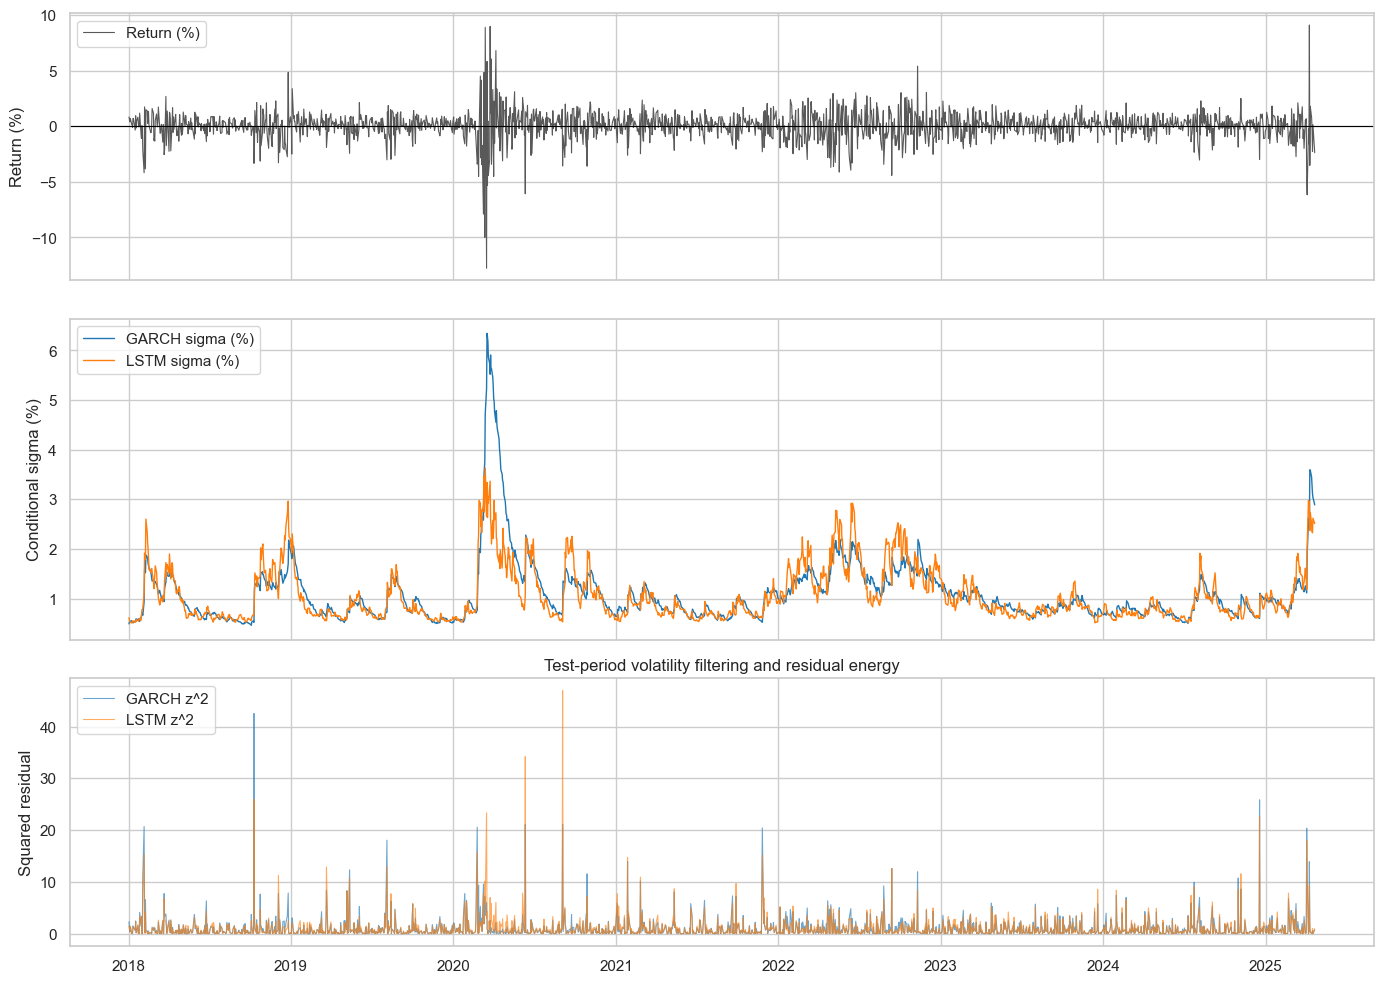

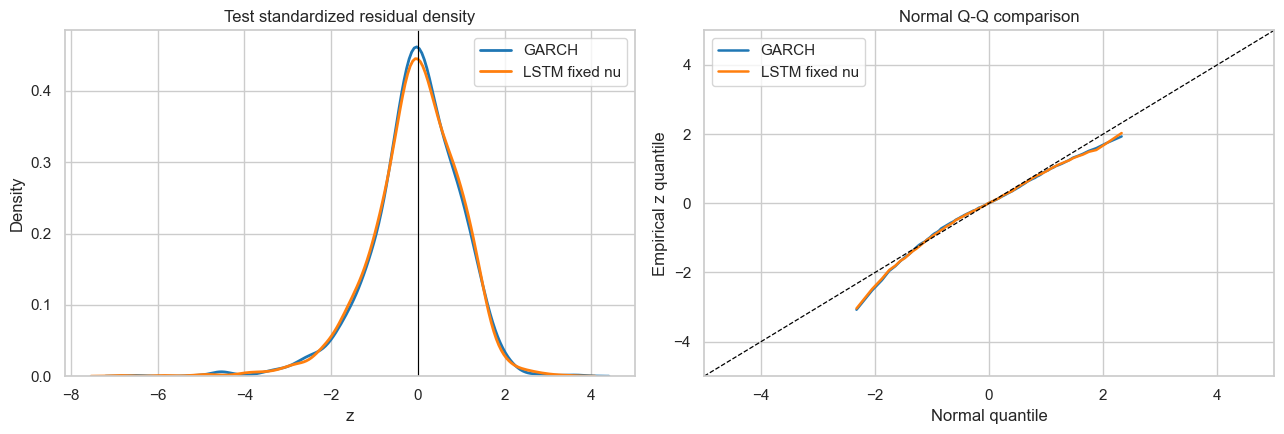

In [10]:
# Pick the fixed-nu seed with the lowest chronological validation NLL for visualization only.
best_fixed = min(fixed_results, key=lambda r: r['best_val_nll'])
best_fixed_metric = next(m for m in fixed_metrics if m['seed'] == best_fixed['seed'])
plot_df = merged.copy()
plot_df['LSTM Sigma'] = best_fixed['sigma_full']
plot_df['LSTM z'] = (plot_df['Return'] - mu_pct) / plot_df['LSTM Sigma']
plot_df['GARCH z'] = plot_df['t Standardized Residuals']
plot_df['Abs Return'] = plot_df['Return'].abs()
print(f"Best fixed-nu LSTM seed for plots: {best_fixed['seed']} (val NLL={best_fixed['best_val_nll']:.4f})")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [1.0, 1.2, 1.0]})
test_plot = plot_df[plot_df['Date'] >= TRAIN_END].copy()
axes[0].plot(test_plot['Date'], test_plot['Return'], color='0.35', lw=0.8, label='Return (%)')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('Return (%)')
axes[0].legend(loc='upper left')

axes[1].plot(test_plot['Date'], test_plot['GARCH Sigma'], color='tab:blue', lw=1.0, label='GARCH sigma (%)')
axes[1].plot(test_plot['Date'], test_plot['LSTM Sigma'], color='tab:orange', lw=1.0, label='LSTM sigma (%)')
axes[1].set_ylabel('Conditional sigma (%)')
axes[1].legend(loc='upper left')

axes[2].plot(test_plot['Date'], test_plot['GARCH z']**2, color='tab:blue', alpha=0.65, lw=0.8, label='GARCH z^2')
axes[2].plot(test_plot['Date'], test_plot['LSTM z']**2, color='tab:orange', alpha=0.65, lw=0.8, label='LSTM z^2')
axes[2].set_ylabel('Squared residual')
axes[2].legend(loc='upper left')
axes[2].set_title('Test-period volatility filtering and residual energy')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for z, label, color in [
    (test_plot['GARCH z'].dropna(), 'GARCH', 'tab:blue'),
    (test_plot['LSTM z'].dropna(), 'LSTM fixed nu', 'tab:orange'),
]:
    sns.kdeplot(z, ax=axes[0], label=label, color=color, lw=2)
    qq = np.quantile(z, np.linspace(0.01, 0.99, 99))
    normal_q = __import__('scipy').stats.norm.ppf(np.linspace(0.01, 0.99, 99))
    axes[1].plot(normal_q, qq, color=color, lw=1.8, label=label)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Test standardized residual density')
axes[0].set_xlabel('z')
axes[0].legend()
lim = [-5, 5]
axes[1].plot(lim, lim, color='black', lw=0.9, ls='--')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_title('Normal Q-Q comparison')
axes[1].set_xlabel('Normal quantile'); axes[1].set_ylabel('Empirical z quantile')
axes[1].legend()
plt.tight_layout()
plt.show()

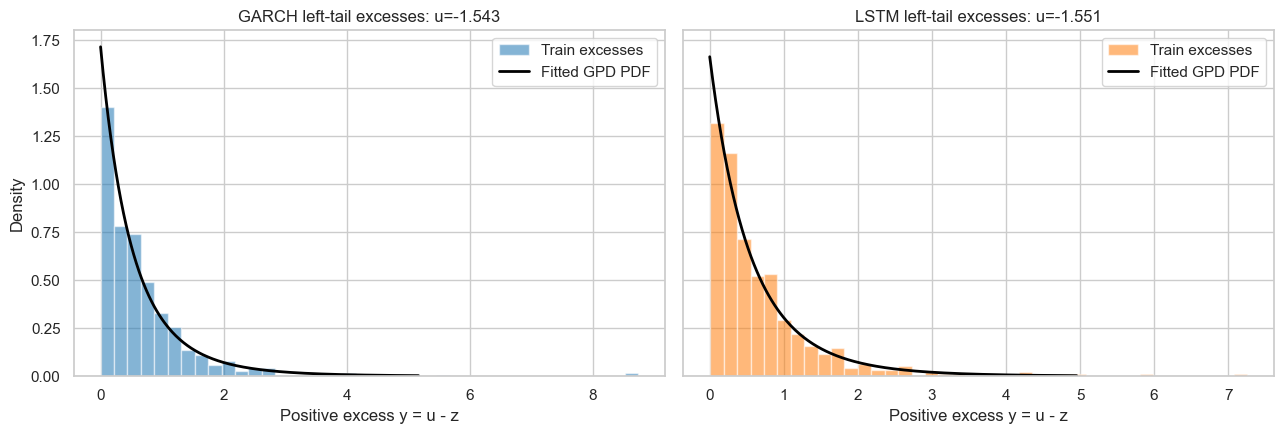

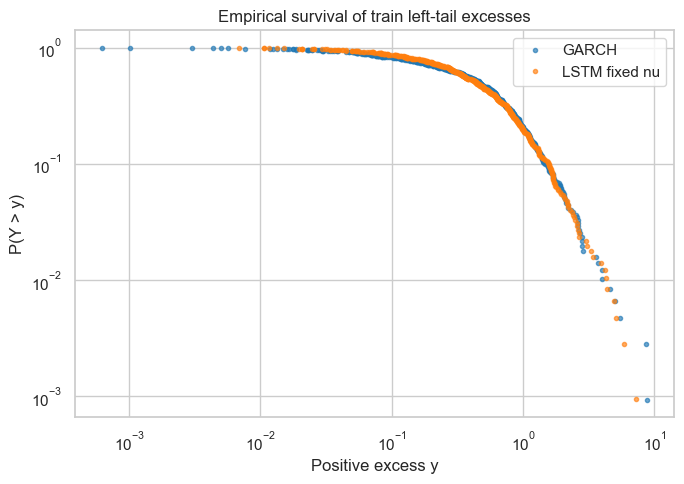

In [11]:
def tail_fit_for_plot(metric, z_series):
    z = np.asarray(z_series, dtype=float)
    z = z[np.isfinite(z)]
    u = metric['u']
    excess = u - z[z < u]
    xi, beta = metric['xi'], metric['gpd_sigma']
    x = np.linspace(0, np.quantile(excess, 0.995), 250)
    return excess, x, genpareto.pdf(x, c=xi, loc=0, scale=beta), u

garch_train_z = plot_df.loc[plot_df['Date'] < TRAIN_END, 'GARCH z']
lstm_train_z = plot_df.loc[plot_df['Date'] < TRAIN_END, 'LSTM z']
g_exc, gx, gpdf, gu = tail_fit_for_plot(garch_metrics, garch_train_z)
l_exc, lx, lpdf, lu = tail_fit_for_plot(best_fixed_metric, lstm_train_z)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].hist(g_exc, bins=40, density=True, alpha=0.55, color='tab:blue', label='Train excesses')
axes[0].plot(gx, gpdf, color='black', lw=2, label='Fitted GPD PDF')
axes[0].set_title(f'GARCH left-tail excesses: u={gu:.3f}')
axes[0].set_xlabel('Positive excess y = u - z')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(l_exc, bins=40, density=True, alpha=0.55, color='tab:orange', label='Train excesses')
axes[1].plot(lx, lpdf, color='black', lw=2, label='Fitted GPD PDF')
axes[1].set_title(f'LSTM left-tail excesses: u={lu:.3f}')
axes[1].set_xlabel('Positive excess y = u - z')
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for exc, label, color in [(g_exc, 'GARCH', 'tab:blue'), (l_exc, 'LSTM fixed nu', 'tab:orange')]:
    sorted_exc = np.sort(exc)
    surv = 1 - (np.arange(1, len(sorted_exc)+1) - 0.5) / len(sorted_exc)
    ax.loglog(sorted_exc, surv, marker='.', ls='none', alpha=0.65, color=color, label=label)
ax.set_title('Empirical survival of train left-tail excesses')
ax.set_xlabel('Positive excess y')
ax.set_ylabel('P(Y > y)')
ax.legend()
plt.tight_layout()
plt.show()

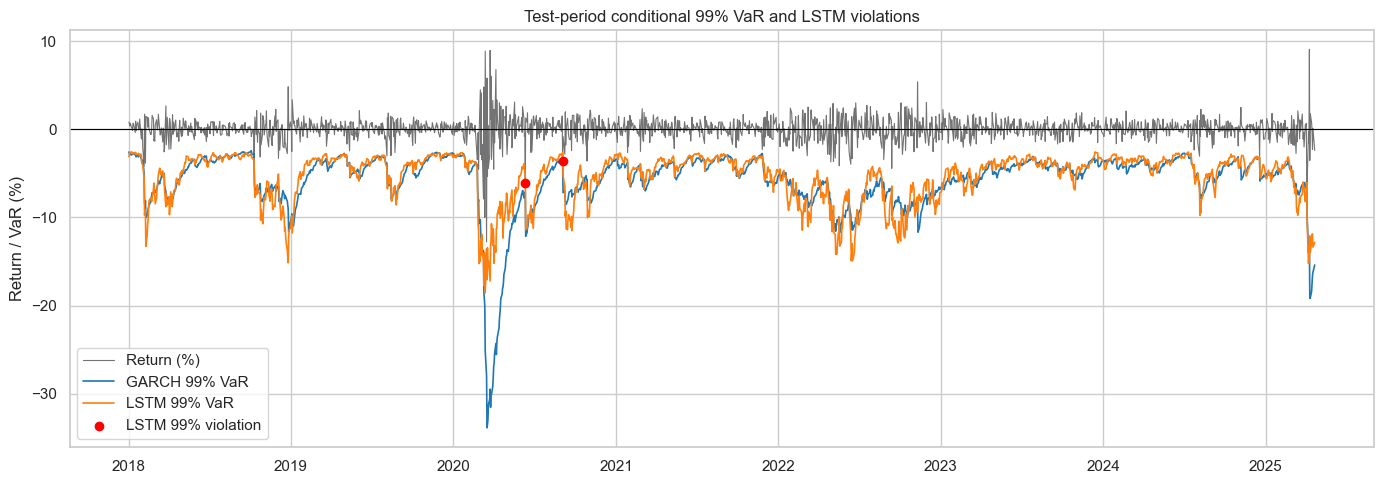

GARCH 99% violations: 1 observed vs 18.35 expected
LSTM 99% violations:  2 observed vs 18.35 expected


In [12]:
# Conditional 99% VaR path and violations for the plotted fixed-nu seed.
z99_lstm = best_fixed_metric['z_99']
z99_garch = garch_metrics['z_99']
test_plot = test_plot.copy()
test_plot['LSTM VaR 99'] = devolatilized_var(z99_lstm, mu_pct, test_plot['LSTM Sigma'])
test_plot['GARCH VaR 99'] = devolatilized_var(z99_garch, mu_pct, test_plot['GARCH Sigma'])
test_plot['LSTM Violation 99'] = test_plot['Return'] < test_plot['LSTM VaR 99']
test_plot['GARCH Violation 99'] = test_plot['Return'] < test_plot['GARCH VaR 99']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_plot['Date'], test_plot['Return'], color='0.45', lw=0.8, label='Return (%)')
ax.plot(test_plot['Date'], test_plot['GARCH VaR 99'], color='tab:blue', lw=1.2, label='GARCH 99% VaR')
ax.plot(test_plot['Date'], test_plot['LSTM VaR 99'], color='tab:orange', lw=1.2, label='LSTM 99% VaR')
viol = test_plot[test_plot['LSTM Violation 99']]
ax.scatter(viol['Date'], viol['Return'], color='red', s=36, zorder=5, label='LSTM 99% violation')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Test-period conditional 99% VaR and LSTM violations')
ax.set_ylabel('Return / VaR (%)')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

print(f"GARCH 99% violations: {int(test_plot['GARCH Violation 99'].sum())} observed vs {0.01*len(test_plot):.2f} expected")
print(f"LSTM 99% violations:  {int(test_plot['LSTM Violation 99'].sum())} observed vs {0.01*len(test_plot):.2f} expected")

## Result

Seed spread is optimizer variance. Tail metrics use few exceedances; whitening diagnostics use the full test period.


In [13]:
rng=np.random.default_rng(2026); viol=np.vstack([m['viol99_seq'] for m in fixed_metrics]).mean(axis=0)
boot=np.array([viol[rng.integers(0,len(viol),len(viol))].sum() for _ in range(2000)])
lo,hi=np.quantile(boot,[0.025,0.975])
print(f'Fixed-nu LSTM seed-mean 99% violation count bootstrap 95% interval: [{lo:.1f}, {hi:.1f}]')
print('Headline comparison table:')
print(comparison.to_string())


Fixed-nu LSTM seed-mean 99% violation count bootstrap 95% interval: [0.2, 6.8]
Headline comparison table:
                                param_count         n_train          n_test                 nu                   u         train_exceed          test_exceed      lb_sq_p_lag10      lb_sq_p_lag22    excess_kurtosis               jb_stat          jb_pvalue                 xi              xi_se          gpd_sigma  gpd_sigma_boot_se    kupiec99_pvalue christoffersen99_pvalue          viol95_obs viol95_expected         viol99_obs viol99_expected conditional_var95_mean conditional_var99_mean unconditional_var95 unconditional_var99
GARCH(1,1)-t                    7.0 +/- 0.0  8318.0 +/- 0.0  1835.0 +/- 0.0  5.7633 +/- 0.0000  -1.5425 +/- 0.0000  533.0000 +/- 0.0000  132.0000 +/- 0.0000  0.0021 +/- 0.0000  0.0679 +/- 0.0000  2.5768 +/- 0.0000   710.6729 +/- 0.0000  0.0000 +/- 0.0000  0.1523 +/- 0.0000  0.0499 +/- 0.0000  0.5827 +/- 0.0000  0.0374 +/- 0.0000  0.0000 +/- 0.0000       0.9736 